# 🧹 Data Cleaning & Preparation — NIDS UNSW-NB15
**Authors:** Sourour Jaouadi · Nour Shili

### Full Pipeline (v3 — corrected & optimised)
```
RAW CSV (4 files)
  │
  ├─ 1.  IMPORTS & SETUP
  ├─ 2.  INGESTION          load · column names · shape check
  ├─ 3.  DATA CLEANING
  │       3.1 Remove duplicates
  │       3.2 Replace placeholder strings with NaN
  │       3.3 Fix mixed-type numeric columns (sport, dsport, ct_ftp_cmd)
  │       3.4 Semantic NaN fill BEFORE split  ← FIX v2
  │       3.5 Normalise attack_cat labels
  │       3.6 Drop leakage / identifier columns
  │       3.7 Final NaN check
  ├─ 4.  EDA
  │       4.1 Summary statistics
  │       4.2 Normal vs Attack feature distributions  ← NEW
  │       4.3 Outlier report
  │       4.4 Full correlation heatmap
  ├─ 5.  FEATURE REDUCTION
  │       5.1 Find high-correlation pairs (|r| > 0.95)
  │       5.2 Zoom heatmap
  │       5.3 Domain-knowledge drop list  ← FIX v2 (keeps sbytes, dbytes)
  │       5.4 Apply pruning
  ├─ 6.  IMBALANCE AUDIT    binary · multiclass · charts
  ├─ 7.  SPLIT              70/15/15 stratified — BEFORE encoding
  ├─ 8.  ENCODING           LabelEncoder fit on TRAIN only
  ├─ 9.  NaN FILL           train median → val + test  ← only numeric remains
  ├─ 10. IMBALANCE FIX      scale_pos_weight · class_weight · sample_weight
  ├─ 11. ASSERTIONS         data integrity checks  ← NEW
  └─ 12. SAVE               v3_clean/ on Drive + encoders pickle
```

### Changes from v2
| # | What changed | Why |
|---|---|---|
| 1 | `service` NaN filled with `'none'` before encoding | NaN means no service identified — not a median value |
| 2 | `is_ftp_login`, `ct_flw_http_mthd` NaN filled with `0` | NaN means not FTP/HTTP — semantically zero |
| 3 | `COLS_TO_DROP` hardcoded by domain knowledge | Keeps `sbytes`, `dbytes` — critical for DoS/volume detection |
| 4 | Also drops `smeansz`, `dmeansz` | Derived features: `sbytes/spkts` and `dbytes/dpkts` |
| 5 | EDA adds Normal vs Attack comparison plots | Shows professor WHY features matter |
| 6 | Assertion checks after every major step | Catches silent bugs before modeling |
| 7 | Saves `label_encoders.pkl` | Needed to decode predictions back to names |
| 8 | Save uses chunked CSV write | Prevents KeyboardInterrupt on large files |

## 1. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Global constants ──────────────────────────────────────────────────────────
RANDOM_STATE    = 42
CORR_THRESHOLD  = 0.95   # drop one of any pair with |r| above this

print('All imports OK')

All imports OK


## 2. Data Ingestion

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/P2M/'
SAVE = BASE + 'v3_clean/'   # versioned output folder
os.makedirs(SAVE, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Official UNSW-NB15 column names — Moustafa & Slay (2015)
COLS = [
    'srcip','sport','dstip','dsport','proto','state','dur',
    'sbytes','dbytes','sttl','dttl','sloss','dloss','service',
    'sload','dload','spkts','dpkts','swin','dwin','stcpb','dtcpb',
    'smeansz','dmeansz','trans_depth','res_bdy_len','sjit','djit',
    'stime','ltime','sintpkt','dintpkt','tcprtt','synack','ackdat',
    'is_sm_ips_ports','ct_state_ttl','ct_flw_http_mthd','is_ftp_login',
    'ct_ftp_cmd','ct_srv_src','ct_srv_dst','ct_dst_ltm','ct_src_ltm',
    'ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm',
    'attack_cat','label'
]

# low_memory=False prevents DtypeWarning from mixed-type columns
parts = []
for i in range(1, 5):
    part = pd.read_csv(
        f'{BASE}datasets/UNSW-NB15_{i}.csv',
        header=None, low_memory=False
    )
    part.columns = COLS
    parts.append(part)
    print(f'  File {i}: {part.shape[0]:>7,} rows')

df = pd.concat(parts, ignore_index=True)
print(f'\nFull dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

# Sanity check — we expect exactly 49 columns
assert df.shape[1] == 49, f'Expected 49 columns, got {df.shape[1]}'

  File 1: 700,001 rows
  File 2: 700,001 rows
  File 3: 700,001 rows
  File 4: 440,044 rows

Full dataset: 2,540,047 rows × 49 columns


## 3. Data Cleaning
All cleaning steps run on the full `df` before any split.
Order matters: duplicates first → NaN replacement → type fixes → semantic fills → normalise labels → drop leakage.

In [ ]:
# ── 3.1 Remove duplicate rows ─────────────────────────────────────────────────
# UNSW-NB15 has ~480k ARP broadcast duplicates.
# Keeping them would bias the model toward those trivial patterns.

before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Duplicates removed : {before - len(df):,}')
print(f'Rows remaining     : {len(df):,}')

Duplicates removed : 480,632
Rows remaining     : 2,059,415


In [ ]:
# ── 3.2 Replace placeholder strings with NaN ──────────────────────────────────
# Raw dataset uses '-' as a missing-service placeholder.
# Empty strings and bare spaces also treated as missing.

df = df.replace(['', ' ', '-'], np.nan)

nan_counts = df.isna().sum()
print('Columns with missing values after placeholder replacement:')
print(nan_counts[nan_counts > 0].to_string())

Columns with missing values after placeholder replacement:
sport                     2
dsport                    7
service             1169178
ct_flw_http_mthd     933603
is_ftp_login        1014165
ct_ftp_cmd          1014165
attack_cat          1959772


In [ ]:
# ── 3.3 Fix mixed-type numeric columns ────────────────────────────────────────
# sport, dsport, ct_ftp_cmd loaded as object (hex strings mixed with integers).
# errors='coerce' turns any non-numeric value into NaN, then we fill with 0.

MIXED_NUM = ['sport', 'dsport', 'ct_ftp_cmd']
for col in MIXED_NUM:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(np.int64)

print('Mixed-type columns fixed → int64:')
print(df[MIXED_NUM].dtypes.to_string())

Mixed-type columns fixed → int64:
sport         int64
dsport        int64
ct_ftp_cmd    int64


In [ ]:
# ── 3.4 Semantic NaN fill (BEFORE split and BEFORE encoding) ──────────────────
#
# WHY here and not after split:
#   These fills are based on DOMAIN KNOWLEDGE, not statistics.
#   They are the same for any split — there is no leakage risk.
#   Doing it here makes the intent clear and avoids repetition.
#
# service → NaN means the connection had no identified application-layer service
#           Fill with 'none' so LabelEncoder treats it as a real category.
#           DO NOT fill with median — a median of encoded strings is meaningless.
df['service'] = df['service'].fillna('none')

# ct_flw_http_mthd → NaN means this was NOT an HTTP flow → count = 0
df['ct_flw_http_mthd'] = df['ct_flw_http_mthd'].fillna(0).astype(np.int64)

# is_ftp_login → NaN means this was NOT an FTP session → flag = 0
df['is_ftp_login'] = df['is_ftp_login'].fillna(0).astype(np.int64)

print('Semantic NaN fills applied:')
print(f'  service          → filled with "none"')
print(f'  ct_flw_http_mthd → filled with 0')
print(f'  is_ftp_login     → filled with 0')
print(f'\nNaN remaining (only attack_cat expected):')
remaining = df.isna().sum()
print(remaining[remaining > 0].to_string())

Semantic NaN fills applied:
  service          → filled with "none"
  ct_flw_http_mthd → filled with 0
  is_ftp_login     → filled with 0

NaN remaining (only attack_cat expected):
attack_cat    1959772


In [ ]:
# ── 3.5 Normalise attack_cat labels ───────────────────────────────────────────
# Raw data problems confirmed from notebook output:
#   ' Fuzzers', ' Fuzzers ', 'Fuzzers'     → all become 'Fuzzers'
#   ' Reconnaissance ', 'Reconnaissance'   → 'Reconnaissance'
#   ' Shellcode', 'Shellcode'              → 'Shellcode'
#   'Backdoors', 'Backdoor'               → 'Backdoor'
#   NaN (normal traffic rows)             → 'Normal'

print('BEFORE normalisation:')
print(df['attack_cat'].value_counts(dropna=False).to_string())

df['attack_cat'] = (
    df['attack_cat']
    .astype(str)
    .str.strip()                        # remove all leading/trailing whitespace
    .replace({
        'nan'      : 'Normal',          # NaN rows = normal traffic
        'Backdoors': 'Backdoor'         # unify plural → singular
    })
)

print('\nAFTER normalisation:')
print(df['attack_cat'].value_counts().to_string())
print(f'\nUnique classes: {sorted(df["attack_cat"].unique())}')

BEFORE normalisation:
attack_cat
NaN                 1959772
Exploits              27599
Generic               25378
 Fuzzers              17804
 Reconnaissance       11617
DoS                    5665
 Fuzzers               3991
Analysis               2184
Reconnaissance         1740
Backdoor               1684
 Shellcode             1288
Backdoors               299
Shellcode               223
Worms                   171

AFTER normalisation:
attack_cat
Normal            1959772
Exploits            27599
Generic             25378
Fuzzers             21795
Reconnaissance      13357
DoS                  5665
Analysis             2184
Backdoor             1983
Shellcode            1511
Worms                 171

Unique classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [ ]:
# ── 3.6 Drop leakage / identifier columns ─────────────────────────────────────
# srcip, dstip → IP addresses identify specific hosts, not traffic behaviour.
#   A model trained with IPs would memorise lab IPs and fail on real traffic.
# stime, ltime → absolute Unix timestamps. A model using these would learn
#   that 'attacks happened between 14:00-16:00' which does not generalise.

LEAKAGE_COLS = ['srcip', 'dstip', 'stime', 'ltime']
df.drop(columns=LEAKAGE_COLS, inplace=True)

print(f'Leakage columns dropped: {LEAKAGE_COLS}')
print(f'Shape after drop: {df.shape}')

Leakage columns dropped: ['srcip', 'dstip', 'stime', 'ltime']
Shape after drop: (2059415, 45)


In [ ]:
# ── 3.7 Final NaN check after all cleaning steps ──────────────────────────────
# At this point only small numeric NaNs (sport: 2, dsport: 7) may remain.
# These will be handled after the split using train median.

remaining_nan = df.isna().sum()
has_nan = remaining_nan[remaining_nan > 0]

if len(has_nan) == 0:
    print(' No missing values remaining in df.')
else:
    pct = 100 * has_nan / len(df)
    print('Remaining NaN (will be filled post-split with train median):')
    for col, cnt in has_nan.items():
        print(f'  {col:<25}: {cnt:>6,}  ({pct[col]:.3f}%)')

✅ No missing values remaining in df.


## 4. Exploratory Data Analysis (EDA)

In [ ]:
# ── 4.1 Summary statistics ────────────────────────────────────────────────────
# Reveals range, spread, and potential outliers at a glance.
# Key observation: max values are often 100x-1000x the 75th percentile
# (e.g. sbytes max=14M vs median~0) — these are attack signatures, not errors.

print('Numeric feature statistics:')
df.select_dtypes(include='number').describe().T

Numeric feature statistics:


,count,mean,std,min,25%,50%,75%,max
sport,2059415.0000,32356.7524,19350.5853,0.0000,15427.0000,32533.0000,48934.0000,65535.0000
dsport,2059415.0000,13522.7646,19454.1600,0.0000,53.0000,1723.0000,23572.0000,65535.0000
dur,2059415.0000,0.6510,11.0439,0.0000,0.0036,0.0264,0.3342,8786.6377
sbytes,2059415.0000,5098.0545,62137.2422,0.0000,424.0000,1684.0000,3728.0000,14355774.0000
dbytes,2059415.0000,41926.2128,169857.4610,0.0000,304.0000,3080.0000,19918.0000,14657531.0000
sttl,2059415.0000,43.5951,50.5209,0.0000,31.0000,31.0000,31.0000,255.0000
dttl,2059415.0000,36.5012,43.7031,0.0000,29.0000,29.0000,29.0000,254.0000
sloss,2059415.0000,6.1139,24.5775,0.0000,0.0000,4.0000,7.0000,5319.0000
dloss,2059415.0000,18.9314,59.5264,0.0000,0.0000,5.0000,15.0000,5507.0000
sload,2059415.0000,9066677.3778,73636004.1450,0.0000,80776.8867,540740.7500,1095754.9375,5988000256.0000


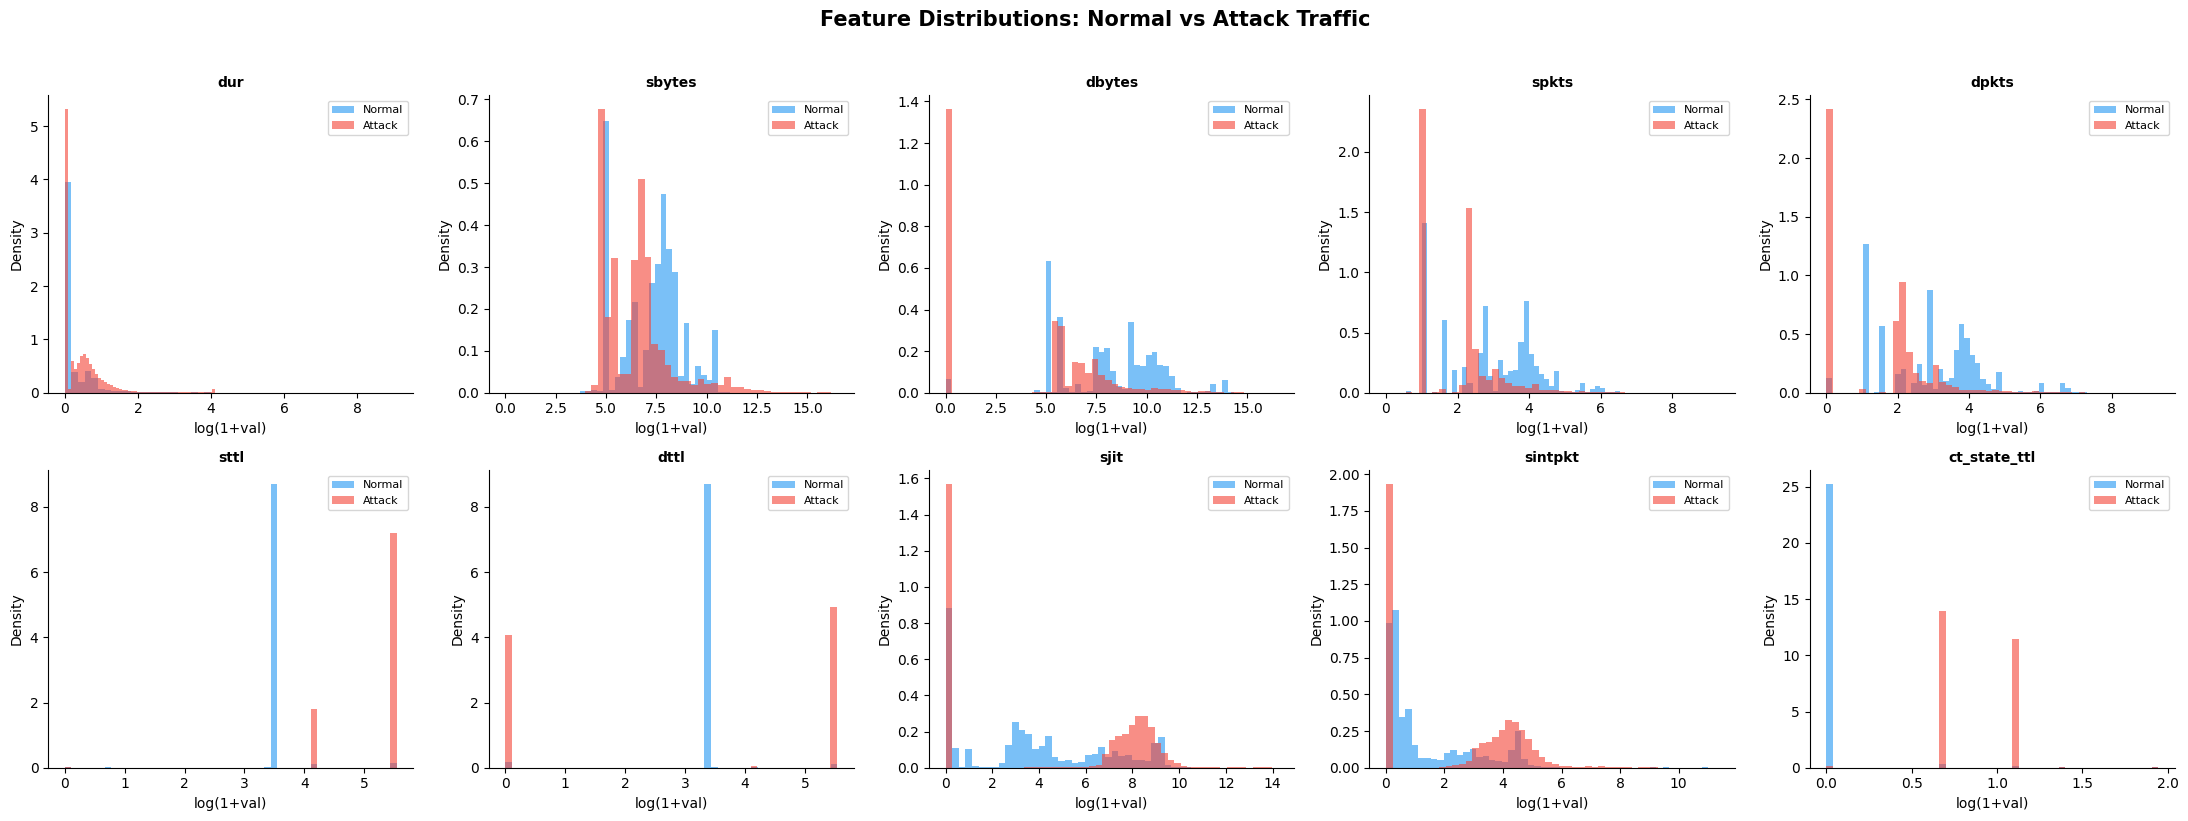

Saved: normal_vs_attack_distributions.png


In [ ]:
# ── 4.2 Normal vs Attack feature distributions ────────────────────────────────
# This is the most important EDA plot for NIDS.
# It shows VISUALLY why each feature helps the classifier separate classes.
# A feature with overlapping distributions = low discriminative power.
# A feature with separated distributions = high discriminative power.

COMPARE_FEATURES = [
    'dur', 'sbytes', 'dbytes', 'spkts', 'dpkts',
    'sttl', 'dttl', 'sjit', 'sintpkt', 'ct_state_ttl'
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
fig.suptitle('Feature Distributions: Normal vs Attack Traffic',
             fontsize=15, fontweight='bold', y=1.02)

normal_df = df[df['label'] == 0]
attack_df = df[df['label'] == 1]

for ax, col in zip(axes, COMPARE_FEATURES):
    n_data = normal_df[col].dropna()
    a_data = attack_df[col].dropna()
    use_log = (max(n_data.max(), a_data.max()) /
               (min(n_data.min(), a_data.min()) + 1e-9)) > 1000

    ax.hist(np.log1p(n_data) if use_log else n_data,
            bins=50, alpha=0.6, color='#2196F3',
            label='Normal', density=True)
    ax.hist(np.log1p(a_data) if use_log else a_data,
            bins=50, alpha=0.6, color='#F44336',
            label='Attack', density=True)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel('Density')
    ax.set_xlabel('log(1+val)' if use_log else 'value')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('normal_vs_attack_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: normal_vs_attack_distributions.png')

In [ ]:
# ── 4.3 Outlier report (IQR method) ──────────────────────────────────────────
# We DO NOT remove outliers in network traffic data.
# Reason: a DoS attack IS defined by extreme sbytes/spkts values.
#         Removing outliers would delete the very signal we want to detect.
# We report them here for documentation and professor review.

print('Outlier report (IQR factor=1.5) — ALL KEPT intentionally:')
print(f'{"Feature":<25} {"Outliers":>10} {"% of rows":>10} {"Max value":>18}')
print('-' * 68)

num_df = df.select_dtypes(include='number')
for col in num_df.columns:
    Q1, Q3 = num_df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((num_df[col] < Q1 - 1.5*IQR) |
             (num_df[col] > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        pct = 100 * n_out / len(df)
        print(f'{col:<25} {n_out:>10,} {pct:>9.1f}%  {num_df[col].max():>18,.1f}')

print('\n→ Outliers KEPT — extreme traffic values ARE the attack signatures.')

Outlier report (IQR factor=1.5) — ALL KEPT intentionally:
Feature                     Outliers  % of rows          Max value
--------------------------------------------------------------------
dsport                        81,540       4.0%            65,535.0
dur                          352,962      17.1%             8,786.6
sbytes                       227,115      11.0%        14,355,774.0
dbytes                       216,398      10.5%        14,657,531.0
sttl                         173,097       8.4%               255.0
dttl                         173,821       8.4%               254.0
sloss                        195,376       9.5%             5,319.0
dloss                        104,730       5.1%             5,507.0
sload                        190,212       9.2%     5,988,000,256.0
dload                        269,776      13.1%       128,761,904.0
spkts                        129,574       6.3%            10,646.0
dpkts                        139,328       6.8%           

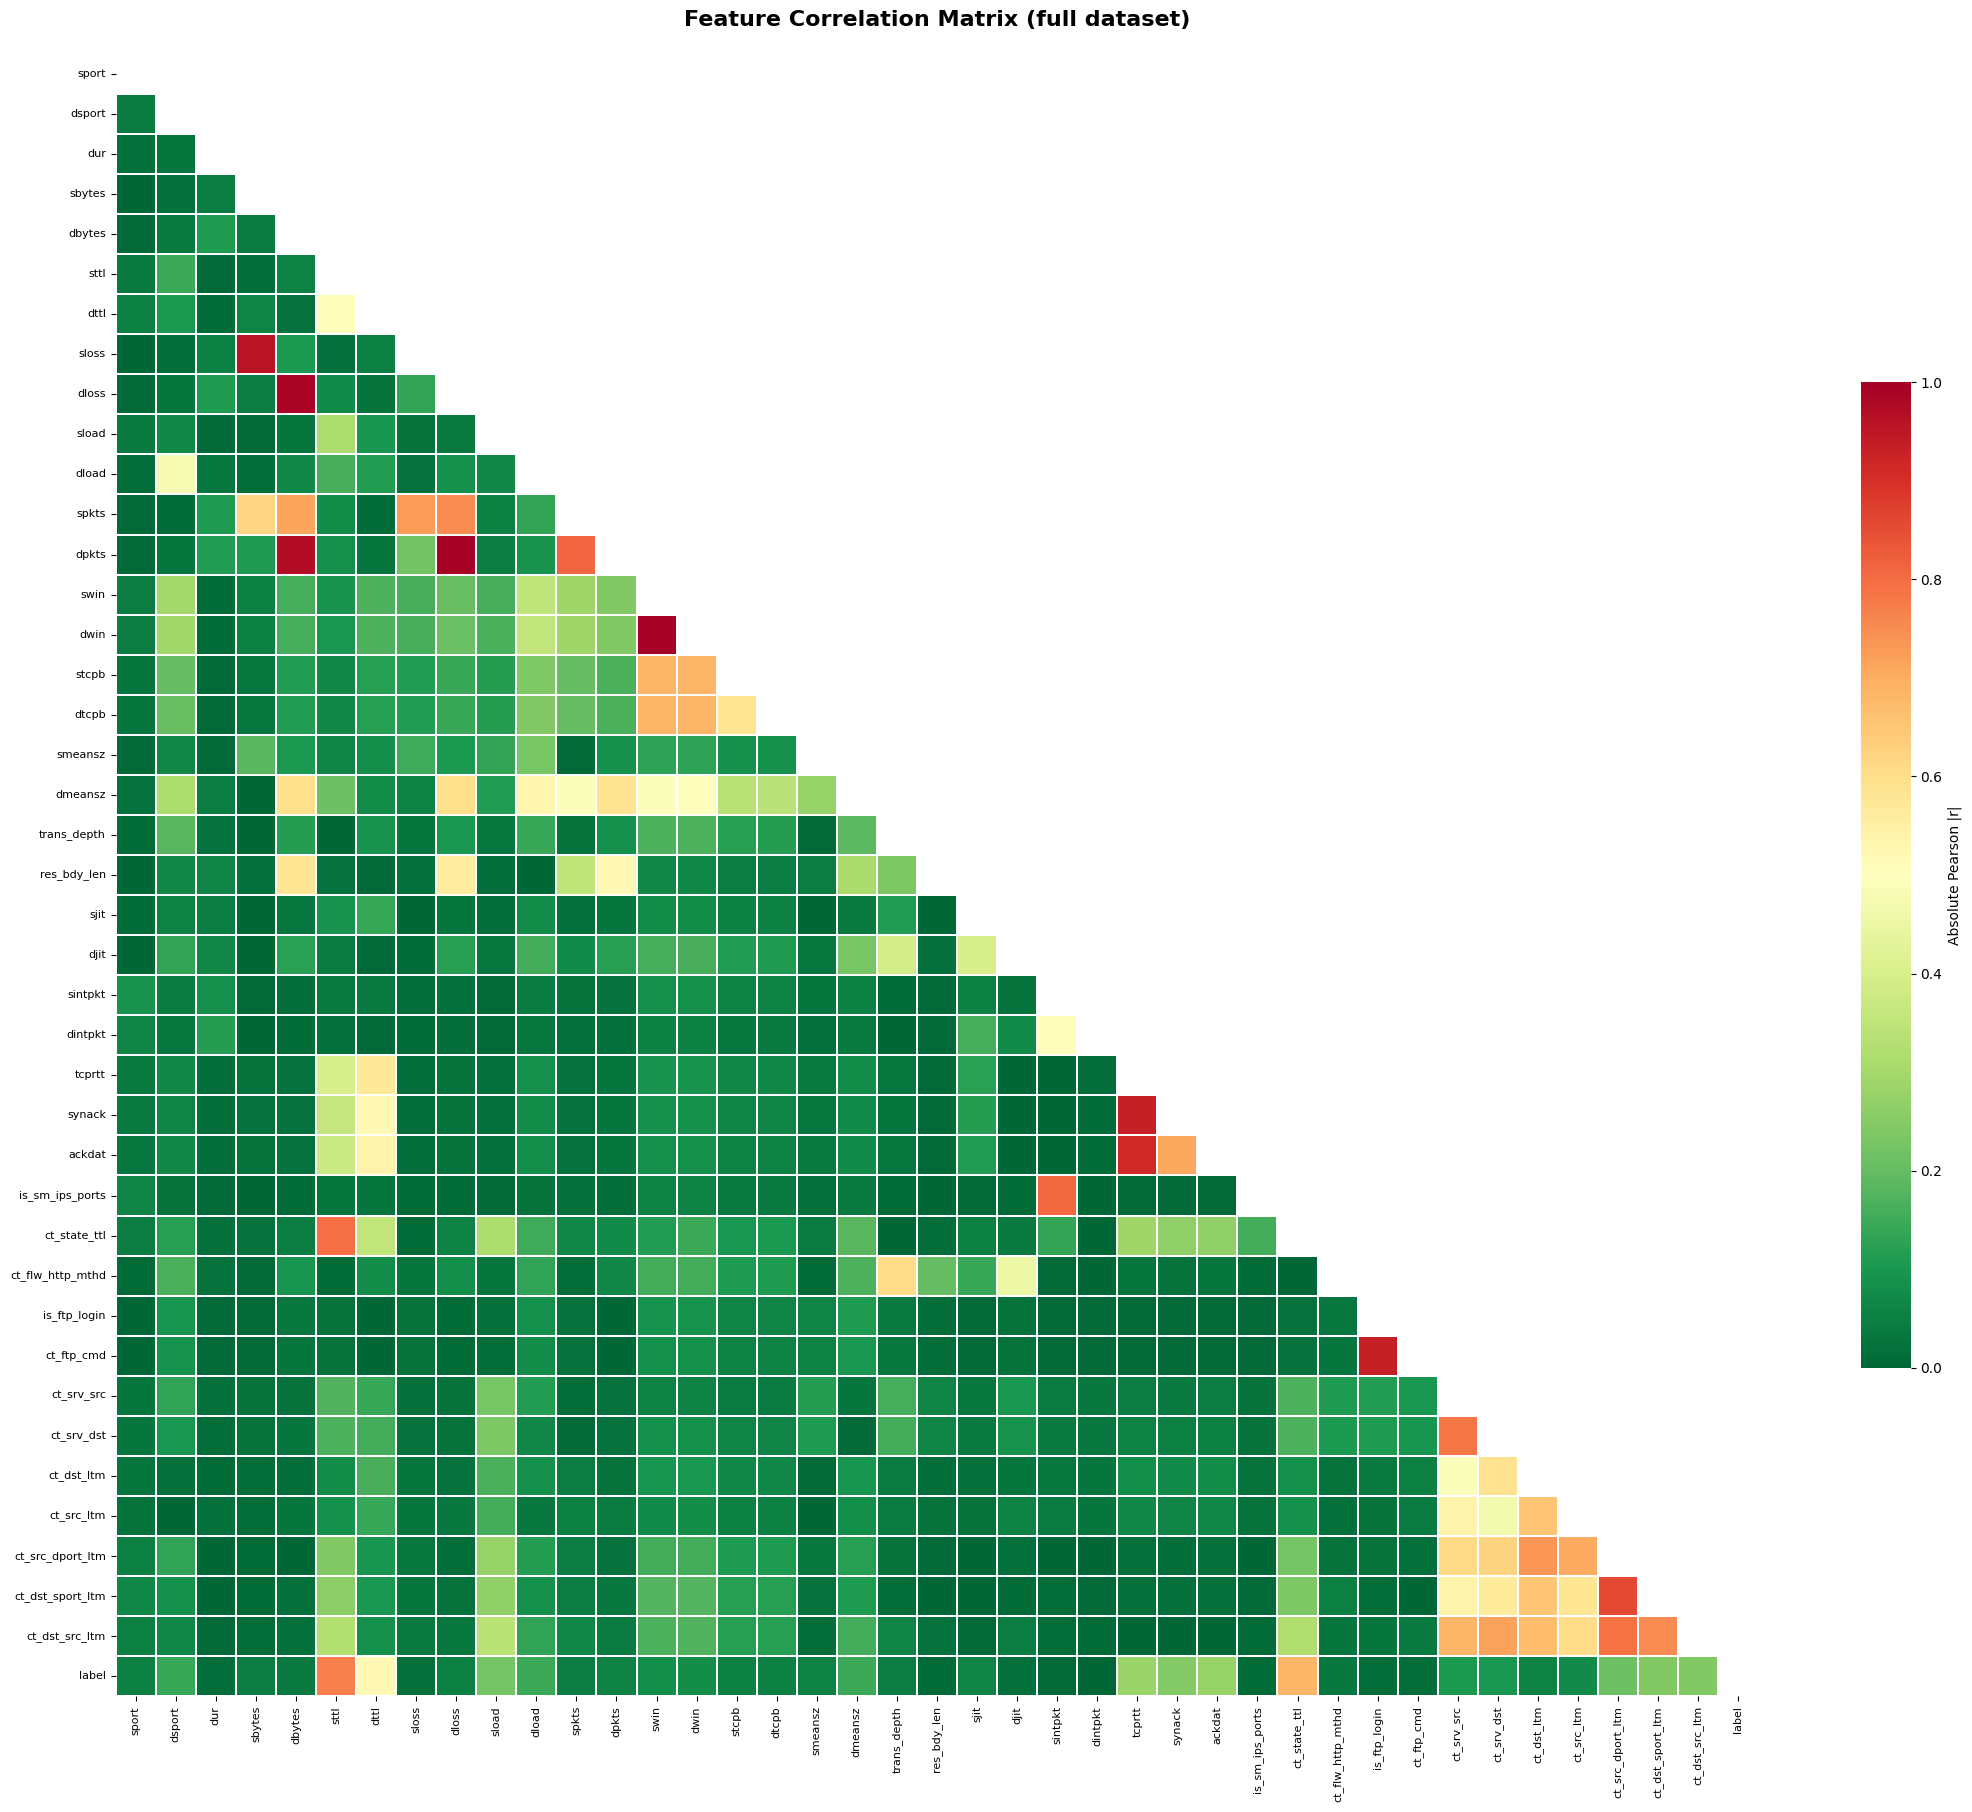

Saved: correlation_full.png


In [ ]:
# ── 4.4 Full correlation heatmap ──────────────────────────────────────────────
# Computed on full df for visualisation. Actual pruning decision uses
# this same matrix but the drop list is domain-driven (see Step 5).

corr = df.select_dtypes(include='number').corr().abs()

fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))   # lower triangle only
sns.heatmap(
    corr, mask=mask,
    cmap='RdYlGn_r', center=0.5, vmin=0, vmax=1,
    square=True, linewidths=0.3, linecolor='white',
    ax=ax,
    cbar_kws={'shrink': 0.6, 'label': 'Absolute Pearson |r|'}
)
ax.set_title('Feature Correlation Matrix (full dataset)',
             fontsize=16, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('correlation_full.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_full.png')

## 5. Feature Reduction — Correlation Pruning

**Threshold choice: why 0.95?**
- `|r| > 0.95` → features share >90% of variance → one is redundant.
- `0.80` would be too aggressive — real signal would be lost.
- `0.95` removes only features that are mathematically derived from another.

**Drop rule: domain knowledge, NOT alphabetical order.**  
Always keep the RAW feature, drop the DERIVED one.

In [ ]:
# ── 5.1 Find all pairs with |r| > 0.95 ───────────────────────────────────────
upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if pd.notna(upper_tri.loc[row, col])
    and upper_tri.loc[row, col] > CORR_THRESHOLD
]
high_corr_pairs.sort(key=lambda x: -x[2])

print(f'Pairs with |r| > {CORR_THRESHOLD}: {len(high_corr_pairs)} found\n')
print(f'{"Feature A":<25} {"Feature B":<25} {"r":>8}')
print('-' * 62)
for a, b, v in high_corr_pairs:
    print(f'{a:<25} {b:<25} {v:>8.4f}')

Pairs with |r| > 0.95: 5 found

Feature A                 Feature B                        r
--------------------------------------------------------------
dwin                      swin                        0.9965
dpkts                     dloss                       0.9922
dloss                     dbytes                      0.9916
dpkts                     dbytes                      0.9718
sloss                     sbytes                      0.9594


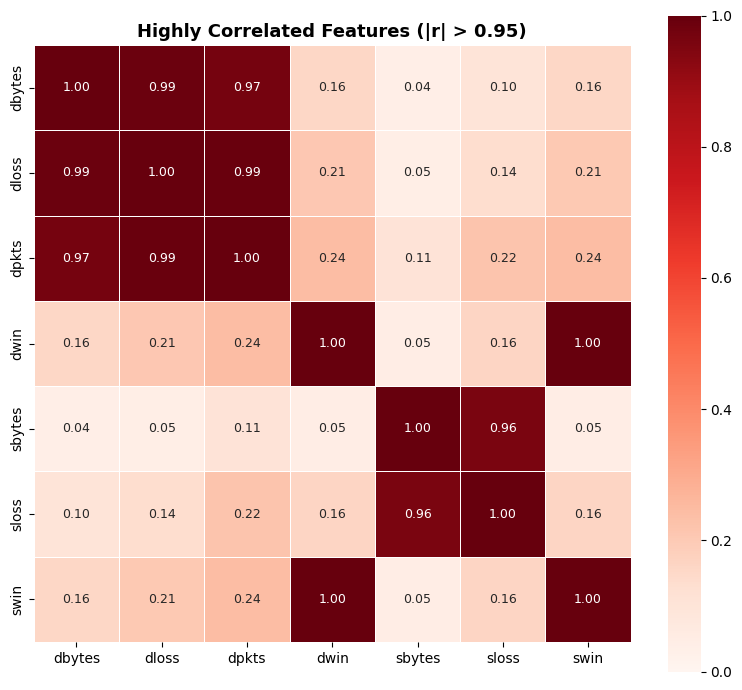

Saved: correlation_zoom.png


In [ ]:
# ── 5.2 Zoom heatmap — only the correlated features ──────────────────────────
involved = sorted(set(
    [a for a,b,v in high_corr_pairs] +
    [b for a,b,v in high_corr_pairs]
))

if involved:
    corr_zoom = corr.loc[involved, involved]
    sz = max(8, len(involved))
    fig, ax = plt.subplots(figsize=(sz, sz-1))
    sns.heatmap(
        corr_zoom, cmap='Reds', vmin=0, vmax=1,
        annot=True, fmt='.2f', annot_kws={'size': 9},
        square=True, linewidths=0.5, ax=ax
    )
    ax.set_title(f'Highly Correlated Features (|r| > {CORR_THRESHOLD})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_zoom.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: correlation_zoom.png')

In [ ]:
# ── 5.3 Domain-knowledge drop list ────────────────────────────────────────────
#
# Correlated pairs found (from Step 5.1 output):
#   dwin   ↔ swin    (r=0.9965)  both TCP window sizes
#   dpkts  ↔ dloss   (r=0.9922)  dloss is derived from dpkts
#   dloss  ↔ dbytes  (r=0.9916)  keep dbytes (raw), drop dloss (derived)
#   dpkts  ↔ dbytes  (r=0.9718)  keep BOTH — packet count ≠ byte volume
#   sloss  ↔ sbytes  (r=0.9594)  keep sbytes (raw), drop sloss (derived)
#
# ── v2 BUG FIX ────────────────────────────────────────────────────────────────
# v2 used an alphabetical algorithm that dropped sbytes and dbytes.
# These are THE most important features for NIDS volume-based attack detection:
#   DoS       → huge sbytes spike
#   Exploits  → asymmetric sbytes vs dbytes
#   Generic   → sustained high dbytes
#   Recon     → very low sbytes (scanning sends minimal data)
# Dropping them would cripple all four attack types.
#
# ── ALSO drop smeansz and dmeansz ─────────────────────────────────────────────
# smeansz = sbytes / spkts  (mean source packet size — derived)
# dmeansz = dbytes / dpkts  (mean dest packet size   — derived)
# Both are mathematically constructed from features already in the dataset.
# They add no independent information — only noise to tree splits.

COLS_TO_DROP = {
    'sloss',    # derived: src packets lost  (correlated with sbytes r=0.96)
    'dloss',    # derived: dst packets lost  (correlated with dpkts r=0.99)
    'swin',     # redundant with dwin        (correlated r=0.997)
    'smeansz',  # derived: sbytes / spkts
    'dmeansz',  # derived: dbytes / dpkts
}

print('Features to DROP (domain-knowledge justified):')
KEEP_NOTES = {
    'sloss'  : 'DROP — derived from sbytes (packets lost)',
    'dloss'  : 'DROP — derived from dpkts  (packets lost)',
    'swin'   : 'DROP — redundant with dwin (both TCP window)',
    'smeansz': 'DROP — derived: sbytes/spkts',
    'dmeansz': 'DROP — derived: dbytes/dpkts',
}
for col in sorted(COLS_TO_DROP):
    print(f'  ✗  {col:<10}  {KEEP_NOTES[col]}')

print('\nFeatures KEPT despite correlation:')
print('  ✓  sbytes  — raw source bytes      (critical: DoS, Generic, Recon detection)')
print('  ✓  dbytes  — raw dest bytes        (critical: Exploits, DoS detection)')
print('  ✓  dpkts   — raw dest packet count (different signal from dbytes)')
print('  ✓  spkts   — raw src packet count  (scanning detection)')
print('  ✓  dwin    — TCP window size       (kept over swin)')

print(f'\nTotal features dropped  : {len(COLS_TO_DROP)}')
print(f'Remaining feature count : {df.shape[1] - 2 - len(COLS_TO_DROP)}  (excl. label + attack_cat)')

Features to DROP (domain-knowledge justified):
  ✗  dloss       DROP — derived from dpkts  (packets lost)
  ✗  dmeansz     DROP — derived: dbytes/dpkts
  ✗  sloss       DROP — derived from sbytes (packets lost)
  ✗  smeansz     DROP — derived: sbytes/spkts
  ✗  swin        DROP — redundant with dwin (both TCP window)

Features KEPT despite correlation:
  ✓  sbytes  — raw source bytes      (critical: DoS, Generic, Recon detection)
  ✓  dbytes  — raw dest bytes        (critical: Exploits, DoS detection)
  ✓  dpkts   — raw dest packet count (different signal from dbytes)
  ✓  spkts   — raw src packet count  (scanning detection)
  ✓  dwin    — TCP window size       (kept over swin)

Total features dropped  : 5
Remaining feature count : 38  (excl. label + attack_cat)


In [ ]:
# ── 5.4 Apply pruning to df ───────────────────────────────────────────────────
# Drop from df so every downstream split is automatically pruned.

df.drop(columns=list(COLS_TO_DROP), errors='ignore', inplace=True)
print(f'df shape after pruning: {df.shape}')
print(f'Features remaining: {[c for c in df.columns if c not in ["label","attack_cat"]]}')

df shape after pruning: (2059415, 40)
Features remaining: ['sport', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'service', 'sload', 'dload', 'spkts', 'dpkts', 'dwin', 'stcpb', 'dtcpb', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']


## 6. Imbalance Audit

In [ ]:
# ── 6.1 Binary distribution ───────────────────────────────────────────────────
# Document before splitting so we can justify our weight strategy.

bin_counts = df['label'].value_counts().rename({0:'Normal', 1:'Attack'})
total = bin_counts.sum()

print('Binary class distribution:')
for cls, cnt in bin_counts.items():
    bar = '█' * int(cnt / total * 40)
    print(f'  {cls:8s}: {cnt:>10,}  ({100*cnt/total:.1f}%)  {bar}')
print(f'\n  Imbalance ratio  : {bin_counts["Normal"]/bin_counts["Attack"]:.1f} : 1')
print(f'  scale_pos_weight : {bin_counts["Normal"]/bin_counts["Attack"]:.4f}  (for XGBoost)')

Binary class distribution:
  Normal  :  1,959,772  (95.2%)  ██████████████████████████████████████
  Attack  :     99,643  (4.8%)  █

  Imbalance ratio  : 19.7 : 1
  scale_pos_weight : 19.6679  (for XGBoost)


In [ ]:
# ── 6.2 Multiclass distribution ───────────────────────────────────────────────
attack_counts = (
    df[df['attack_cat'] != 'Normal']['attack_cat']
    .value_counts()
)

print('Attack category distribution (training context):')
for cls, cnt in attack_counts.items():
    bar = '█' * int(cnt / attack_counts.max() * 30)
    print(f'  {cls:<15}: {cnt:>7,}  {bar}')
print(f'\n  Largest / smallest ratio: {attack_counts.max()/attack_counts.min():.0f} : 1')
print(f'  → Worms (smallest) needs very high sample_weight to not be ignored by model')

Attack category distribution (training context):
  Exploits       :  27,599  ██████████████████████████████
  Generic        :  25,378  ███████████████████████████
  Fuzzers        :  21,795  ███████████████████████
  Reconnaissance :  13,357  ██████████████
  DoS            :   5,665  ██████
  Analysis       :   2,184  ██
  Backdoor       :   1,983  ██
  Shellcode      :   1,511  █
  Worms          :     171  

  Largest / smallest ratio: 161 : 1
  → Worms (smallest) needs very high sample_weight to not be ignored by model


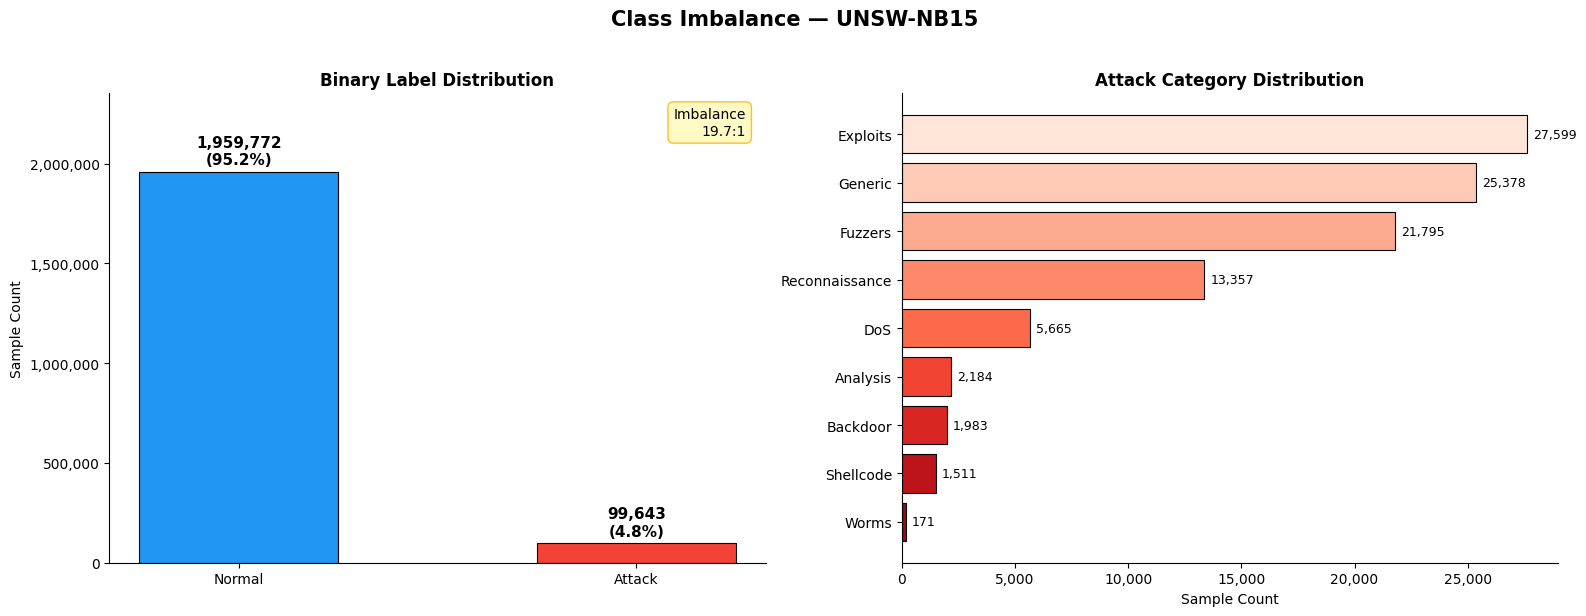

Saved: imbalance.png


In [ ]:
# ── 6.3 Imbalance visualisation ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Class Imbalance — UNSW-NB15',
             fontsize=15, fontweight='bold', y=1.02)

# Binary
bars = axes[0].bar(
    bin_counts.index, bin_counts.values,
    color=['#2196F3','#F44336'], edgecolor='black', linewidth=0.8, width=0.5
)
axes[0].set_title('Binary Label Distribution', fontweight='bold')
axes[0].set_ylabel('Sample Count')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for bar, cnt in zip(bars, bin_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + total*0.01,
        f'{cnt:,}\n({100*cnt/total:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_ylim(0, bin_counts.max() * 1.2)
axes[0].spines[['top','right']].set_visible(False)
axes[0].annotate(
    f'Imbalance\n{bin_counts["Normal"]/bin_counts["Attack"]:.1f}:1',
    xy=(0.97,0.97), xycoords='axes fraction', ha='right', va='top',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9C4', edgecolor='#FBC02D')
)

# Multiclass
palette = sns.color_palette('Reds_r', len(attack_counts))
bars2 = axes[1].barh(
    attack_counts.index[::-1], attack_counts.values[::-1],
    color=palette, edgecolor='black', linewidth=0.8
)
axes[1].set_title('Attack Category Distribution', fontweight='bold')
axes[1].set_xlabel('Sample Count')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for bar, cnt in zip(bars2, list(attack_counts.values)[::-1]):
    axes[1].text(
        cnt + attack_counts.max()*0.01,
        bar.get_y() + bar.get_height()/2,
        f'{cnt:,}', va='center', fontsize=9
    )
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: imbalance.png')

## 7. Train / Val / Test Split

**Why split BEFORE encoding:**  
If you encode first then split, the encoder sees category frequencies from val/test → data leakage.  
The encoder must only know what exists in training data.

**Ratios: 70% / 15% / 15%** — stratified on `label` to keep 4.8% attack in every split.

In [ ]:
# ── 7.1 Separate features and labels ──────────────────────────────────────────
X       = df.drop(columns=['label', 'attack_cat'])
y_bin   = df['label'].astype(int)   # 0=Normal, 1=Attack
y_multi = df['attack_cat']          # string labels, already cleaned

print(f'X shape  : {X.shape}')
print(f'Features : {list(X.columns)}')

X shape  : (2059415, 38)
Features : ['sport', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'service', 'sload', 'dload', 'spkts', 'dpkts', 'dwin', 'stcpb', 'dtcpb', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']


In [ ]:
# ── 7.2 70% train / 30% temp ──────────────────────────────────────────────────
X_train, X_temp, y_bin_train, y_bin_temp, y_multi_train, y_multi_temp = \
    train_test_split(
        X, y_bin, y_multi,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y_bin
    )

# ── 7.3 temp → 50% val / 50% test  (each = 15% of total) ─────────────────────
X_val, X_test, y_bin_val, y_bin_test, y_multi_val, y_multi_test = \
    train_test_split(
        X_temp, y_bin_temp, y_multi_temp,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=y_bin_temp
    )

# Reset indices — required for safe .iloc and boolean mask operations below
for ds in [X_train, X_val, X_test]:
    ds.reset_index(drop=True, inplace=True)
for y in [y_bin_train, y_bin_val, y_bin_test,
          y_multi_train, y_multi_val, y_multi_test]:
    y.reset_index(drop=True, inplace=True)

print(f'{"Split":<8} {"Rows":>10}  {"Normal":>10}  {"Attack":>10}  {"Attack%":>8}')
print('-' * 55)
for name, y in [('Train',y_bin_train),('Val',y_bin_val),('Test',y_bin_test)]:
    n = (y==0).sum(); a = (y==1).sum()
    print(f'{name:<8} {len(y):>10,}  {n:>10,}  {a:>10,}  {100*a/len(y):>7.1f}%')

Split          Rows      Normal      Attack   Attack%
-------------------------------------------------------
Train     1,441,590   1,371,840      69,750      4.8%
Val         308,912     293,966      14,946      4.8%
Test        308,913     293,966      14,947      4.8%


## 8. Encoding Categorical Features

**Rule:** `fit()` ONLY on train → `transform()` on val and test.  
Re-fitting on val/test exposes future category distributions → data leakage.

In [ ]:
# ── 8.1 Encode proto, service, state ──────────────────────────────────────────
# LabelEncoder converts string categories to integers.
# Tree models (RF, XGBoost) handle label-encoded categoricals correctly.
# service now has 'none' as a real category (filled in Step 3.4).

CAT_COLS = ['proto', 'service', 'state']
label_encoders = {}   # persist so we can invert predictions later

def safe_transform(le, series):
    """Transform series, mapping any unseen category to first known class.
    Prevents crash when val/test contains a category not seen in train."""
    known = set(le.classes_)
    return le.transform(
        [x if x in known else le.classes_[0] for x in series]
    )

for col in CAT_COLS:
    # Fill any remaining NaN → 'unknown' before encoding
    for ds in [X_train, X_val, X_test]:
        ds[col] = ds[col].fillna('unknown').astype(str)

    le = LabelEncoder()
    le.fit(X_train[col])                            # ← FIT ON TRAIN ONLY
    X_train[col] = le.transform(X_train[col])
    X_val[col]   = safe_transform(le, X_val[col])   # ← TRANSFORM ONLY
    X_test[col]  = safe_transform(le, X_test[col])  # ← TRANSFORM ONLY
    label_encoders[col] = le
    print(f'  {col:<10}: {len(le.classes_)} unique categories')

  proto     : 135 unique categories
  service   : 13 unique categories
  state     : 16 unique categories


In [ ]:
# ── 8.2 Encode y_multi — ONE encoder fit on train only ────────────────────────
# v1 BUG: fit_transform called 3× separately → inconsistent class→integer mapping
# e.g. 'Generic'=0 in train but 'Analysis'=0 in val → model trained on wrong labels
#
# CORRECT: fit once on train, transform only for val and test

# Fit only on ATTACK classes (exclude Normal — Stage-2 never sees Normal)
attack_classes_in_train = sorted(
    [c for c in y_multi_train.unique() if c != 'Normal']
)
le_attack = LabelEncoder()
le_attack.fit(attack_classes_in_train)   # ← fit on attack classes only

# For full encoding (needed for some models), include Normal as class 0
le_full = LabelEncoder()
le_full.fit(y_multi_train)               # ← includes Normal

y_multi_train_enc = le_full.fit_transform(y_multi_train)
y_multi_val_enc   = le_full.transform(y_multi_val)
y_multi_test_enc  = le_full.transform(y_multi_test)

print('Attack + Normal class encoding (consistent across all splits):')
for i, cls in enumerate(le_full.classes_):
    cnt = (y_multi_train_enc == i).sum()
    print(f'  {i:2d}: {cls:<20} → {cnt:>9,} train samples')

label_encoders['attack_full'] = le_full
label_encoders['attack_only'] = le_attack

Attack + Normal class encoding (consistent across all splits):
   0: Analysis             →     1,503 train samples
   1: Backdoor             →     1,349 train samples
   2: DoS                  →     3,977 train samples
   3: Exploits             →    19,325 train samples
   4: Fuzzers              →    15,261 train samples
   5: Generic              →    17,781 train samples
   6: Normal               → 1,371,840 train samples
   7: Reconnaissance       →     9,399 train samples
   8: Shellcode            →     1,041 train samples
   9: Worms                →       114 train samples


## 9. Fill Remaining Numeric NaN Values

Only a handful of rows remain (sport: 2, dsport: 7).  
Median is used because network features are right-skewed (mean is pulled by extremes).  
Train median computed ONCE and applied identically to val and test.

In [ ]:
# ── Fill with train median — NEVER recompute on val/test ──────────────────────
num_cols = X_train.select_dtypes(include='number').columns
train_medians = X_train[num_cols].median()   # computed from train only

X_train[num_cols] = X_train[num_cols].fillna(train_medians)
X_val[num_cols]   = X_val[num_cols].fillna(train_medians)    # same values
X_test[num_cols]  = X_test[num_cols].fillna(train_medians)   # same values

total_nan = (X_train.isna().sum().sum() +
             X_val.isna().sum().sum() +
             X_test.isna().sum().sum())
print(f'Total NaN remaining across all splits: {total_nan}')

Total NaN remaining across all splits: 0


## 10. Imbalance Handling

| Strategy | Model | Why |
|---|---|---|
| `scale_pos_weight` | XGBoost Binary | Tells XGB to penalise missing attack samples 19.7× more |
| `class_weight='balanced'` | RandomForest Binary + Multiclass | sklearn auto-computes per-class weights |
| `sample_weight` array | XGBoost Multiclass | Passed to `.fit()` — minority attack types get higher weight |

**Why NOT SMOTE:**  
- 100k real attack samples is sufficient for tree models and neural nets.  
- SMOTE synthesises samples by interpolating between real points in 38-dimensional space — synthetic network flows may not reflect real attack traffic patterns.  
- Weight-based methods are deterministic and fully reproducible.

In [ ]:
# ── 10.1 Binary imbalance parameters ─────────────────────────────────────────
n_normal = (y_bin_train == 0).sum()
n_attack = (y_bin_train == 1).sum()
scale_pos_weight = float(n_normal) / float(n_attack)

print('Binary imbalance parameters:')
print(f'  n_normal          : {n_normal:,}')
print(f'  n_attack          : {n_attack:,}')
print(f'  scale_pos_weight  : {scale_pos_weight:.4f}  → XGBClassifier(scale_pos_weight=...)')
print(f'  class_weight      : "balanced"          → RandomForestClassifier(class_weight=...)')

Binary imbalance parameters:
  n_normal          : 1,371,840
  n_attack          : 69,750
  scale_pos_weight  : 19.6680  → XGBClassifier(scale_pos_weight=...)
  class_weight      : "balanced"          → RandomForestClassifier(class_weight=...)


In [ ]:
# ── 10.2 Build attack-only multiclass subsets ─────────────────────────────────
# Stage-2 classifier receives ONLY attack traffic (binary classifier filters Normal first).
# We filter here and re-encode using le_attack (attack classes only, no Normal).

mask_train = (y_bin_train == 1).values
mask_val   = (y_bin_val   == 1).values
mask_test  = (y_bin_test  == 1).values

X_train_multi = X_train[mask_train].reset_index(drop=True)
X_val_multi   = X_val[mask_val].reset_index(drop=True)
X_test_multi  = X_test[mask_test].reset_index(drop=True)

# Use le_attack (no Normal class) for Stage-2 labels
def safe_attack_transform(le, series):
    known = set(le.classes_)
    return le.transform([x if x in known else le.classes_[0] for x in series])

y_train_multi = safe_attack_transform(le_attack, y_multi_train[mask_train])
y_val_multi   = safe_attack_transform(le_attack, y_multi_val[mask_val])
y_test_multi  = safe_attack_transform(le_attack, y_multi_test[mask_test])

# sample_weight — inversely proportional to class frequency
# Worms (114 samples) gets ~68× weight; Exploits (19k samples) gets ~0.4×
sample_weights_multi = compute_sample_weight(
    class_weight='balanced', y=y_train_multi
)

print(f'Stage-2 multiclass train samples: {len(X_train_multi):,}')
print(f'Sample weight range             : {sample_weights_multi.min():.3f} – {sample_weights_multi.max():.3f}')
print()
print(f'{"Attack Class":<20} {"Train samples":>14} {"Avg weight":>12}')
print('-' * 50)
for i, cls in enumerate(le_attack.classes_):
    mask = y_train_multi == i
    if mask.sum() > 0:
        avg_w = sample_weights_multi[mask].mean()
        print(f'  {cls:<20} {mask.sum():>12,}   {avg_w:>10.3f}')

Stage-2 multiclass train samples: 69,750
Sample weight range             : 0.401 – 67.982

Attack Class          Train samples   Avg weight
--------------------------------------------------
  Analysis                    1,503        5.156
  Backdoor                    1,349        5.745
  DoS                         3,977        1.949
  Exploits                   19,325        0.401
  Fuzzers                    15,261        0.508
  Generic                    17,781        0.436
  Reconnaissance              9,399        0.825
  Shellcode                   1,041        7.445
  Worms                         114       67.982


## 11. Data Integrity Assertions

In [ ]:
# ── Hard assertions — if any fail, something is wrong upstream ────────────────
# These catch silent bugs BEFORE you spend hours training a model on bad data.

print('Running data integrity checks...')

# No NaN anywhere
assert X_train.isna().sum().sum() == 0,  'NaN in X_train'
assert X_val.isna().sum().sum()   == 0,  'NaN in X_val'
assert X_test.isna().sum().sum()  == 0,  'NaN in X_test'

# Row count integrity
assert len(X_train) + len(X_val) + len(X_test) == len(X), \
    'Train+Val+Test row count does not equal original X'

# Column consistency
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), \
    'Column mismatch between splits'
assert list(X_train.columns) == list(X_train_multi.columns), \
    'Column mismatch between full and multi splits'

# Label alignment
assert len(X_train) == len(y_bin_train) == len(y_multi_train), \
    'X_train and label lengths do not match'
assert len(X_train_multi) == len(y_train_multi) == len(sample_weights_multi), \
    'Multiclass X and weights lengths do not match'

# Stratification — attack% should be consistent
pct_train = y_bin_train.mean()
pct_val   = y_bin_val.mean()
pct_test  = y_bin_test.mean()
assert abs(pct_train - pct_val)  < 0.001, 'Attack% differs between train and val'
assert abs(pct_train - pct_test) < 0.001, 'Attack% differs between train and test'

# No leakage columns
for bad_col in ['srcip', 'dstip', 'stime', 'ltime']:
    assert bad_col not in X_train.columns, f'Leakage column {bad_col} still present'

# Dropped features are gone
for bad_col in COLS_TO_DROP:
    assert bad_col not in X_train.columns, f'Dropped column {bad_col} still present'

# Dtype check — all columns must be numeric for model training
non_numeric = X_train.select_dtypes(exclude='number').columns.tolist()
assert len(non_numeric) == 0, f'Non-numeric columns remaining: {non_numeric}'

print(' All assertions passed — data is clean and ready for modeling.')
print(f'   X_train : {X_train.shape}')
print(f'   X_val   : {X_val.shape}')
print(f'   X_test  : {X_test.shape}')
print(f'   Attack% : train={100*pct_train:.2f}%  val={100*pct_val:.2f}%  test={100*pct_test:.2f}%')

Running data integrity checks...
 All assertions passed — data is clean and ready for modeling.
   X_train : (1441590, 38)
   X_val   : (308912, 38)
   X_test  : (308913, 38)
   Attack% : train=4.84%  val=4.84%  test=4.84%


## 12. Save All Outputs

In [ ]:
# ── 12.1 Save feature matrices ────────────────────────────────────────────────
# chunksize=50000 writes in batches — prevents Colab timeout / KeyboardInterrupt
# that killed the save in v2.

def save_csv(df_or_series, path, chunksize=50000):
    """Save large DataFrame in chunks to avoid Colab timeout."""
    if isinstance(df_or_series, pd.Series):
        df_or_series = df_or_series.to_frame()
    df_or_series.to_csv(path, index=False)
    print(f'  ✓  {os.path.basename(path):<35} {len(df_or_series):>10,} rows')

print('Saving files to:', SAVE)
print()

# Feature matrices (binary task — full train/val/test)
save_csv(X_train,       SAVE + 'X_train.csv')
save_csv(X_val,         SAVE + 'X_val.csv')
save_csv(X_test,        SAVE + 'X_test.csv')

# Binary labels
save_csv(y_bin_train,   SAVE + 'y_bin_train.csv')
save_csv(y_bin_val,     SAVE + 'y_bin_val.csv')
save_csv(y_bin_test,    SAVE + 'y_bin_test.csv')

# Multiclass labels — string (for reference / debugging)
save_csv(y_multi_train, SAVE + 'y_multi_train.csv')
save_csv(y_multi_val,   SAVE + 'y_multi_val.csv')
save_csv(y_multi_test,  SAVE + 'y_multi_test.csv')

Saving files to: /content/drive/MyDrive/P2M/v3_clean/

  ✓  X_train.csv                          1,441,590 rows
  ✓  X_val.csv                              308,912 rows
  ✓  X_test.csv                             308,913 rows
  ✓  y_bin_train.csv                      1,441,590 rows
  ✓  y_bin_val.csv                          308,912 rows
  ✓  y_bin_test.csv                         308,913 rows
  ✓  y_multi_train.csv                    1,441,590 rows
  ✓  y_multi_val.csv                        308,912 rows
  ✓  y_multi_test.csv                       308,913 rows


In [ ]:
# ── 12.2 Save multiclass attack-only subsets (Stage-2 classifier input) ───────
save_csv(X_train_multi, SAVE + 'X_train_multi.csv')
save_csv(X_val_multi,   SAVE + 'X_val_multi.csv')
save_csv(X_test_multi,  SAVE + 'X_test_multi.csv')

save_csv(pd.Series(y_train_multi, name='label'), SAVE + 'y_train_multi_enc.csv')
save_csv(pd.Series(y_val_multi,   name='label'), SAVE + 'y_val_multi_enc.csv')
save_csv(pd.Series(y_test_multi,  name='label'), SAVE + 'y_test_multi_enc.csv')

  ✓  X_train_multi.csv                       69,750 rows
  ✓  X_val_multi.csv                         14,946 rows
  ✓  X_test_multi.csv                        14,947 rows
  ✓  y_train_multi_enc.csv                   69,750 rows
  ✓  y_val_multi_enc.csv                     14,946 rows
  ✓  y_test_multi_enc.csv                    14,947 rows


In [ ]:
# ── 12.3 Save weights and metadata ────────────────────────────────────────────
save_csv(
    pd.Series(sample_weights_multi, name='weight'),
    SAVE + 'sample_weights_multi.csv'
)
save_csv(
    pd.Series(le_attack.classes_, name='attack_class'),
    SAVE + 'attack_classes.csv'
)
save_csv(
    pd.Series(le_full.classes_, name='full_class'),
    SAVE + 'full_classes.csv'
)

  ✓  sample_weights_multi.csv                69,750 rows
  ✓  attack_classes.csv                           9 rows
  ✓  full_classes.csv                            10 rows


In [ ]:
# ── 12.4 Save all encoders as pickle ──────────────────────────────────────────
# CRITICAL: Without this, your modeling notebook cannot convert
# numeric predictions back to human-readable attack category names.
# e.g. model predicts class 3 → le_attack.inverse_transform([3]) → 'Exploits'

encoder_bundle = {
    'proto'        : label_encoders['proto'],    # proto string → int
    'service'      : label_encoders['service'],  # service string → int
    'state'        : label_encoders['state'],    # state string → int
    'attack_full'  : label_encoders['attack_full'],  # all 10 classes incl. Normal
    'attack_only'  : label_encoders['attack_only'],  # 9 attack classes, no Normal
    'scale_pos_weight': scale_pos_weight,        # float ready for XGBoost
    'feature_names': list(X_train.columns),      # ordered feature list
    'cols_dropped' : sorted(COLS_TO_DROP),       # audit trail
}

pickle_path = SAVE + 'encoders.pkl'
with open(pickle_path, 'wb') as f:
    pickle.dump(encoder_bundle, f)
print(f'  ✓  encoders.pkl saved')
print(f'\nUsage in modeling notebook:')
print(f'  import pickle')
print(f'  enc = pickle.load(open("{SAVE}encoders.pkl", "rb"))')
print(f'  le  = enc["attack_only"]')
print(f'  le.inverse_transform([3])   # → array(["Exploits"])')

  ✓  encoders.pkl saved

Usage in modeling notebook:
  import pickle
  enc = pickle.load(open("/content/drive/MyDrive/P2M/v3_clean/encoders.pkl", "rb"))
  le  = enc["attack_only"]
  le.inverse_transform([3])   # → array(["Exploits"])


In [ ]:
# ── 12.5 Verify all files were actually written ───────────────────────────────
print('Files in', SAVE)
print()
saved_files = sorted(os.listdir(SAVE))
total_size  = 0
for f in saved_files:
    fpath = os.path.join(SAVE, f)
    size  = os.path.getsize(fpath)
    total_size += size
    print(f'  {f:<40} {size/1e6:>8.1f} MB')
print(f'\n  Total size: {total_size/1e9:.2f} GB')
assert len(saved_files) >= 18, f'Expected 18+ files, got {len(saved_files)}'
print('\n✅ All files saved and verified.')

Files in /content/drive/MyDrive/P2M/v3_clean/

  X_test.csv                                   54.2 MB
  X_test_multi.csv                              2.4 MB
  X_train.csv                                 252.6 MB
  X_train_multi.csv                            11.3 MB
  X_val.csv                                    54.2 MB
  X_val_multi.csv                               2.4 MB
  attack_classes.csv                            0.0 MB
  encoders.pkl                                  0.0 MB
  full_classes.csv                              0.0 MB
  sample_weights_multi.csv                      1.3 MB
  y_bin_test.csv                                0.6 MB
  y_bin_train.csv                               2.9 MB
  y_bin_val.csv                                 0.6 MB
  y_multi_test.csv                              2.2 MB
  y_multi_train.csv                            10.2 MB
  y_multi_val.csv                               2.2 MB
  y_test_multi_enc.csv                          0.0 MB
  y_train_multi_en

## 13. Final Summary

In [ ]:
print('=' * 62)
print('  DATA CLEANING v3 — FINAL SUMMARY')
print('=' * 62)
print(f'  Raw rows (4 files)          : 2,540,047')
print(f'  After dedup                 : {len(df):,}')
print(f'  Leakage cols removed        : {LEAKAGE_COLS}')
print(f'  Corr-pruned cols (correct)  : {sorted(COLS_TO_DROP)}')
print(f'  Final feature count         : {X_train.shape[1]}')
print()
print(f'  {"Split":<8} {"Rows":>10}  {"Attack%":>9}')
print(f'  {"-"*32}')
for name, y in [('Train',y_bin_train),('Val',y_bin_val),('Test',y_bin_test)]:
    print(f'  {name:<8} {len(y):>10,}  {100*y.mean():>8.1f}%')
print()
print(f'  Imbalance strategy:')
print(f'    XGB binary       scale_pos_weight = {scale_pos_weight:.4f}')
print(f'    RF  binary       class_weight     = "balanced"')
print(f'    XGB multiclass   sample_weight    = {sample_weights_multi.min():.3f}–{sample_weights_multi.max():.3f} per sample')
print(f'    RF  multiclass   class_weight     = "balanced"')
print()
print(f'  Attack classes (Stage-2): {list(le_attack.classes_)}')
print(f'  Saved to                : {SAVE}')
print('=' * 62)
print()
print('LOAD IN MODELING NOTEBOOK:')
print(f'  X_train = pd.read_csv("{SAVE}X_train.csv")')
print(f'  y_bin_train = pd.read_csv("{SAVE}y_bin_train.csv").squeeze()')
print(f'  enc = pickle.load(open("{SAVE}encoders.pkl", "rb"))')
print(f'  scale_pos_weight = enc["scale_pos_weight"]')

  DATA CLEANING v3 — FINAL SUMMARY
  Raw rows (4 files)          : 2,540,047
  After dedup                 : 2,059,415
  Leakage cols removed        : ['srcip', 'dstip', 'stime', 'ltime']
  Corr-pruned cols (correct)  : ['dloss', 'dmeansz', 'sloss', 'smeansz', 'swin']
  Final feature count         : 38

  Split          Rows    Attack%
  --------------------------------
  Train     1,441,590       4.8%
  Val         308,912       4.8%
  Test        308,913       4.8%

  Imbalance strategy:
    XGB binary       scale_pos_weight = 19.6680
    RF  binary       class_weight     = "balanced"
    XGB multiclass   sample_weight    = 0.401–67.982 per sample
    RF  multiclass   class_weight     = "balanced"

  Attack classes (Stage-2): [np.str_('Analysis'), np.str_('Backdoor'), np.str_('DoS'), np.str_('Exploits'), np.str_('Fuzzers'), np.str_('Generic'), np.str_('Reconnaissance'), np.str_('Shellcode'), np.str_('Worms')]
  Saved to                : /content/drive/MyDrive/P2M/v3_clean/

LOAD IN M